# 19 — Attention Head Analysis

Per-head decomposition of what each attention head has learned, across the three
full-dataset attention checkpoints trained this summer at different head counts
(`heads2`, the `n_heads=4` champion, `heads8` — see the phase G head-count ablation).
Performance-wise the ablation already showed `n_heads=4` is the champion (best test
Pearson r); this notebook asks a different question — not "which head count wins,"
but "what does each head specialize in, and does that specialization change with
head count."

Reuses the existing per-element/per-residue attention-weight infrastructure in
`src/analysis/embedding_analysis.py` (`collect_attention_stats`,
`collect_attention_stats_residue`) rather than building new tooling — the same
functions notebook 14 already uses for a single checkpoint, extended here across
three.

**Scope note:** this covers chemistry-level markers only (element identity,
residue identity, and a derived electronegativity-weighted view) — the kind of
"one head learns electronegative atoms" question. Structural/functional markers
like binding-pocket proximity are explicitly out of scope: no pocket-detection
data exists anywhere in this codebase (confirmed directly), and building that
annotation pipeline was already deferred ("that's for later").

## Sections
- **1** Load all three checkpoints, collect per-element and per-residue attention stats
- **2** Per-element attention weight by head, one panel per head-count config
- **3** Per-residue attention weight heatmap, one panel per head-count config
- **4** Specialization score — does more heads mean sharper per-head differentiation?
- **5** Electronegativity-weighted head affinity
- **6** Decision

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path("../..").resolve()))

from src.analysis.embedding_analysis import (
    ELEMENT_NAMES,
    RESIDUE_NAMES,
    collect_attention_stats,
    collect_attention_stats_residue,
    load_model_frozen,
)
from src.data.dataset import load_split_manifest
from src.utils.config import get_data_root

import torch


/home/student/miniconda3/envs/pyg_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configuration

Three full-dataset attention checkpoints, differing only in `n_heads`. All other
architecture/training hyperparameters are identical (see `sweeps/phase_g_head_ablation.yaml`).

In [2]:
THESIS_ROOT = Path("/home/student/thesis")
CKPT_ROOT   = THESIS_ROOT / "checkpoints" / "full_dataset"

DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_ROOT = get_data_root()

CONFIGS = [
    (2, CKPT_ROOT / "attention_heads2"),
    (4, CKPT_ROOT / "attention_aa4_aq2_qq16"),   # champion, n_heads=4
    (8, CKPT_ROOT / "attention_heads8"),
]

for n_heads, ckpt_dir in CONFIGS:
    print(f"n_heads={n_heads}: {ckpt_dir}  (exists: {ckpt_dir.exists()})")


n_heads=2: /home/student/thesis/checkpoints/full_dataset/attention_heads2  (exists: True)
n_heads=4: /home/student/thesis/checkpoints/full_dataset/attention_aa4_aq2_qq16  (exists: True)
n_heads=8: /home/student/thesis/checkpoints/full_dataset/attention_heads8  (exists: True)


---
## 1. Load models & collect attention stats

One test-split pass per checkpoint (848 full-dataset test proteins), inference only —
no weights are modified. This is the expensive cell; results are cached in Python for
every section below.

In [3]:
_, _, test_ids = load_split_manifest(DATA_ROOT)
print(f"Collecting attention stats over {len(test_ids)} test proteins, {len(CONFIGS)} checkpoints...")

element_stats = {}   # n_heads -> {element_name: {"mean": [.]*n_heads, "std": [.]*n_heads, "count": int}}
residue_stats = {}   # n_heads -> {residue_name: {...}}

for n_heads, ckpt_dir in CONFIGS:
    if not ckpt_dir.exists():
        print(f"  SKIP n_heads={n_heads} — checkpoint not found")
        continue
    model, ckpt = load_model_frozen(ckpt_dir, DEVICE)
    print(f"  n_heads={n_heads}: loaded {ckpt['model_name']}, "
          f"parameters={sum(p.numel() for p in model.parameters()):,}")
    element_stats[n_heads] = collect_attention_stats(model, test_ids, DATA_ROOT, DEVICE)
    residue_stats[n_heads] = collect_attention_stats_residue(model, test_ids, DATA_ROOT, DEVICE)
    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

print("Done.")


  n_heads=2: loaded attention, parameters=2,151,106


  n_heads=4: loaded attention, parameters=2,151,138


  n_heads=8: loaded attention, parameters=2,151,202


Done.


---
## 2. Per-element attention weight by head

Mean attention weight α per element per head. A flat distribution across elements
means a head attends by geometric proximity alone; systematic differentiation means
the head is using atom chemistry.

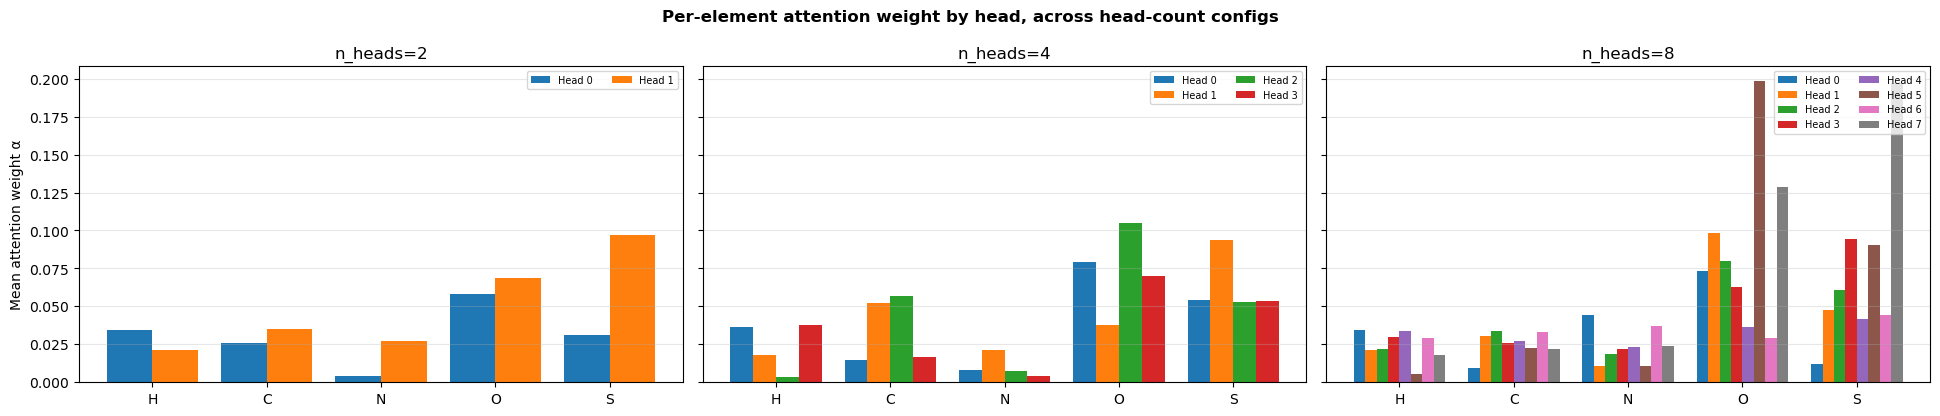

In [4]:
available = [n for n, _ in CONFIGS if n in element_stats]
fig, axes = plt.subplots(1, len(available), figsize=(6.5 * len(available), 4.2), sharey=True)
if len(available) == 1:
    axes = [axes]

for ax, n_heads in zip(axes, available):
    stats = element_stats[n_heads]
    present = [(name, stats[name]) for name in ELEMENT_NAMES if stats[name]["count"] > 0]
    names   = [p[0] for p in present]
    means   = np.array([p[1]["mean"] for p in present])   # (n_elem, n_heads)

    x = np.arange(len(names))
    w = 0.8 / n_heads
    for h in range(n_heads):
        ax.bar(x + h * w - 0.4 + w / 2, means[:, h], width=w, label=f"Head {h}")
    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.set_title(f"n_heads={n_heads}")
    ax.legend(loc="upper right", fontsize=7, ncol=2)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Mean attention weight α")
fig.suptitle("Per-element attention weight by head, across head-count configs", fontweight="bold")
fig.tight_layout()
plt.show()


---
## 3. Per-residue attention weight heatmap

Does the model attend differently depending on which amino acid an atom belongs to,
and does that pattern change with head count?

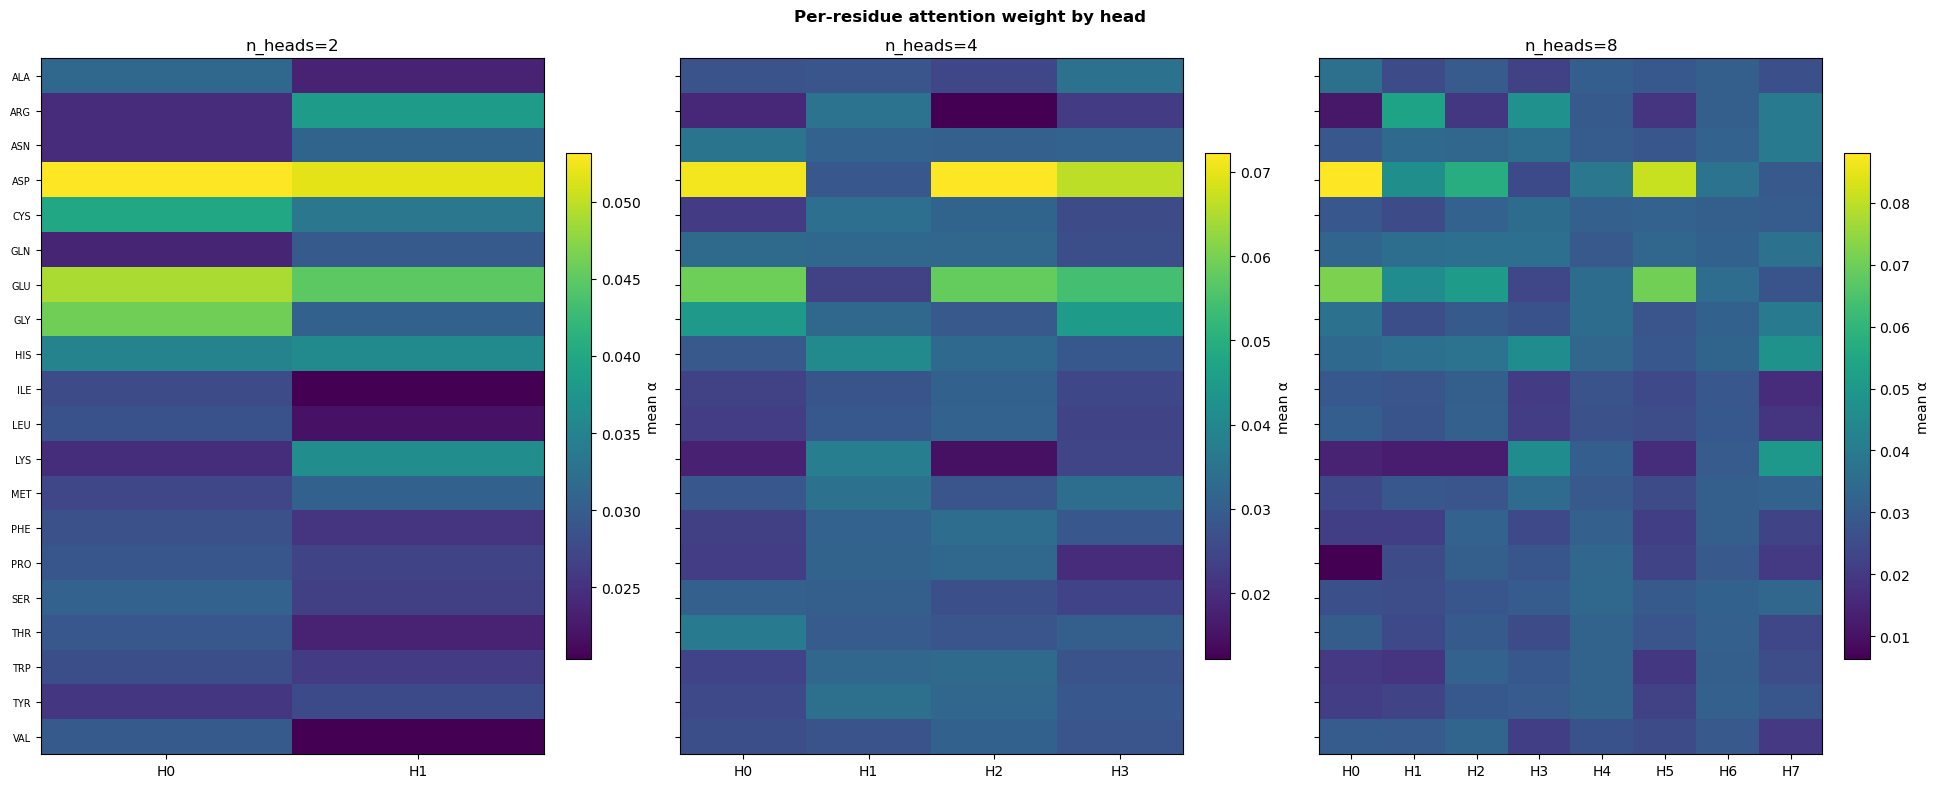

In [5]:
fig, axes = plt.subplots(1, len(available), figsize=(6.5 * len(available), 8), sharey=True)
if len(available) == 1:
    axes = [axes]

for ax, n_heads in zip(axes, available):
    stats = residue_stats[n_heads]
    present = [(name, stats[name]) for name in RESIDUE_NAMES if stats[name]["count"] > 0]
    names   = [p[0] for p in present]
    means   = np.array([p[1]["mean"] for p in present])   # (n_res, n_heads)

    im = ax.imshow(means, aspect="auto", cmap="viridis")
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=7)
    ax.set_xticks(range(n_heads))
    ax.set_xticklabels([f"H{h}" for h in range(n_heads)])
    ax.set_title(f"n_heads={n_heads}")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="mean α")

fig.suptitle("Per-residue attention weight by head", fontweight="bold")
fig.tight_layout()
plt.show()


---
## 4. Specialization score — does more heads mean sharper differentiation?

For each head, take the standard deviation of its mean-α across elements — a head
attending uniformly regardless of element has low std; a head that strongly favors
certain elements has high std. Averaged across heads within a config, this gives one
specialization score per head-count config.

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


n_heads=2: per-head element-α std = [0.0175 0.0286]  (mean=0.0230)
n_heads=4: per-head element-α std = [0.0262 0.0276 0.0371 0.024 ]  (mean=0.0287)
n_heads=8: per-head element-α std = [0.0234 0.0309 0.0236 0.0277 0.0066 0.073  0.0057 0.0727]  (mean=0.0330)


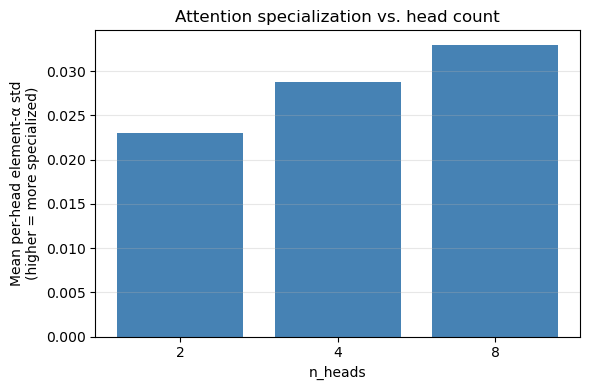

In [6]:
spec_scores = {}
for n_heads in available:
    stats = element_stats[n_heads]
    present = [stats[name]["mean"] for name in ELEMENT_NAMES if stats[name]["count"] > 0]
    means = np.array(present)   # (n_elem, n_heads)
    per_head_std = means.std(axis=0)   # (n_heads,)
    spec_scores[n_heads] = per_head_std
    print(f"n_heads={n_heads}: per-head element-α std = "
          f"{np.array2string(per_head_std, precision=4)}  (mean={per_head_std.mean():.4f})")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([str(n) for n in available], [spec_scores[n].mean() for n in available], color="steelblue")
ax.set_xlabel("n_heads")
ax.set_ylabel("Mean per-head element-α std\n(higher = more specialized)")
ax.set_title("Attention specialization vs. head count")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()


---
## 5. Electronegativity-weighted head affinity

A derived view not in the existing tooling: weight each head's per-element mean-α by
that element's Pauling electronegativity, giving one score per head — a head that
leans toward attending to electronegative atoms (O, N) scores high; a head leaning
toward electropositive/neutral atoms (H, C) scores low. `unknown` is excluded (no
well-defined electronegativity).

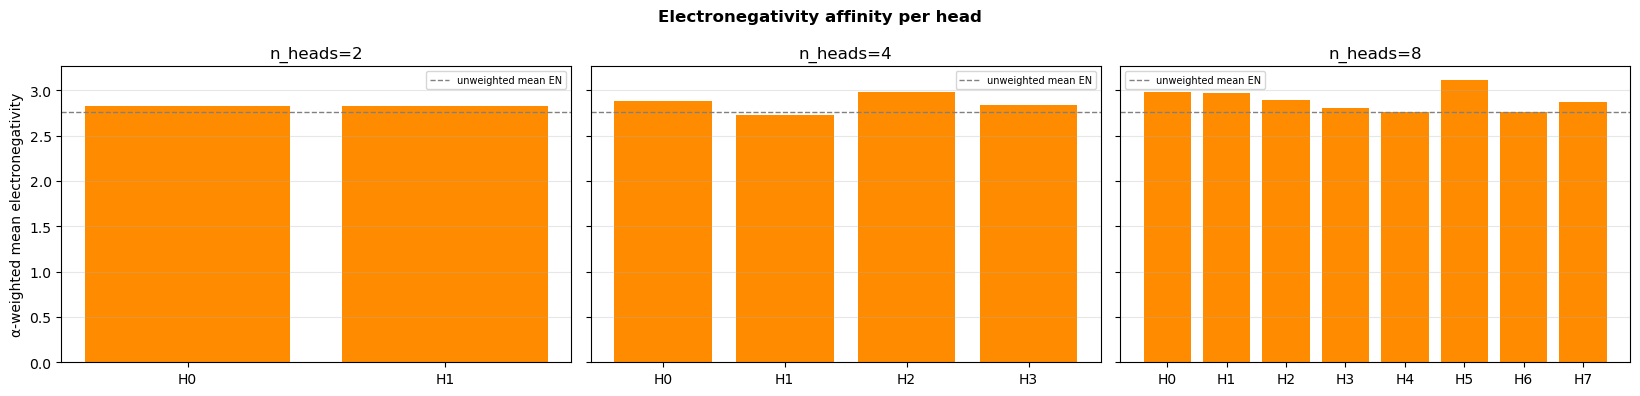

In [7]:
PAULING_ELECTRONEGATIVITY = {
    "H": 2.20, "C": 2.55, "N": 3.04, "O": 3.44, "S": 2.58,
}

fig, axes = plt.subplots(1, len(available), figsize=(5.5 * len(available), 4), sharey=True)
if len(available) == 1:
    axes = [axes]

for ax, n_heads in zip(axes, available):
    stats = element_stats[n_heads]
    # weighted mean electronegativity per head, weighted by that element's mean-alpha
    weighted = np.zeros(n_heads)
    weight_sum = np.zeros(n_heads)
    for name, en in PAULING_ELECTRONEGATIVITY.items():
        if stats[name]["count"] == 0:
            continue
        alpha = np.array(stats[name]["mean"])   # (n_heads,)
        weighted   += alpha * en
        weight_sum += alpha
    head_en = weighted / np.maximum(weight_sum, 1e-8)

    ax.bar(range(n_heads), head_en, color="darkorange")
    ax.axhline(np.mean(list(PAULING_ELECTRONEGATIVITY.values())), color="gray", ls="--", lw=1,
               label="unweighted mean EN")
    ax.set_xticks(range(n_heads))
    ax.set_xticklabels([f"H{h}" for h in range(n_heads)])
    ax.set_title(f"n_heads={n_heads}")
    ax.legend(fontsize=7)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("α-weighted mean electronegativity")
fig.suptitle("Electronegativity affinity per head", fontweight="bold")
fig.tight_layout()
plt.show()


---
## 6. Decision

*Fill in once reviewed.*

| n_heads | Most electronegative-leaning head | Most specialized head | Overall specialization (mean std) |
|---|---|---|---|
| 2 | ? | ? | ? |
| 4 | ? | ? | ? |
| 8 | ? | ? | ? |

**Reasoning:** *does head specialization sharpen with more heads, or does it stay
diffuse regardless of count? Does any head's electronegativity affinity line up with
a chemically sensible story (e.g. one head consistently favoring O/N)?*